# Dependence-character transitions: exploratory scout

Question: does SPI–SPI track an independently defined change beyond signed/absolute Pearson and the vector of all SPI means? These are separate comparisons. No advantage is presumed; this notebook keeps physical checks, failed candidates and the compositional control separate.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'configs/analysis/dependence-transition-261005.yaml').is_file())
RESULTS = ROOT / 'results/order-parameter-inference/dependence-transition-261005'
def show(relative):
    display(Image(filename=str(RESULTS / relative), width=1100))

## Physical candidates: generalized synchronization

A response can become a reproducible nonlinear function of a chaotic drive without their signals becoming equal. The largest conditional response Lyapunov exponent measures whether response perturbations grow or contract. An independently initialized auxiliary response checks convergence, but is **excluded** from the observed MTS. Ground truth is measured on a disjoint, longer future trajectory.

The sweep compares a Rössler pair, Rössler driving Lorenz, and driven logistic modules. For the flows, $M=N=6$ observed states; the auxiliary and tangent variables are diagnostic only. The first figure uses **11 cheap probes, not p90**; four seeds fit PC1 and four evaluate it. Shading in the first column spans the two pooled reference-half estimates, not a confidence interval.

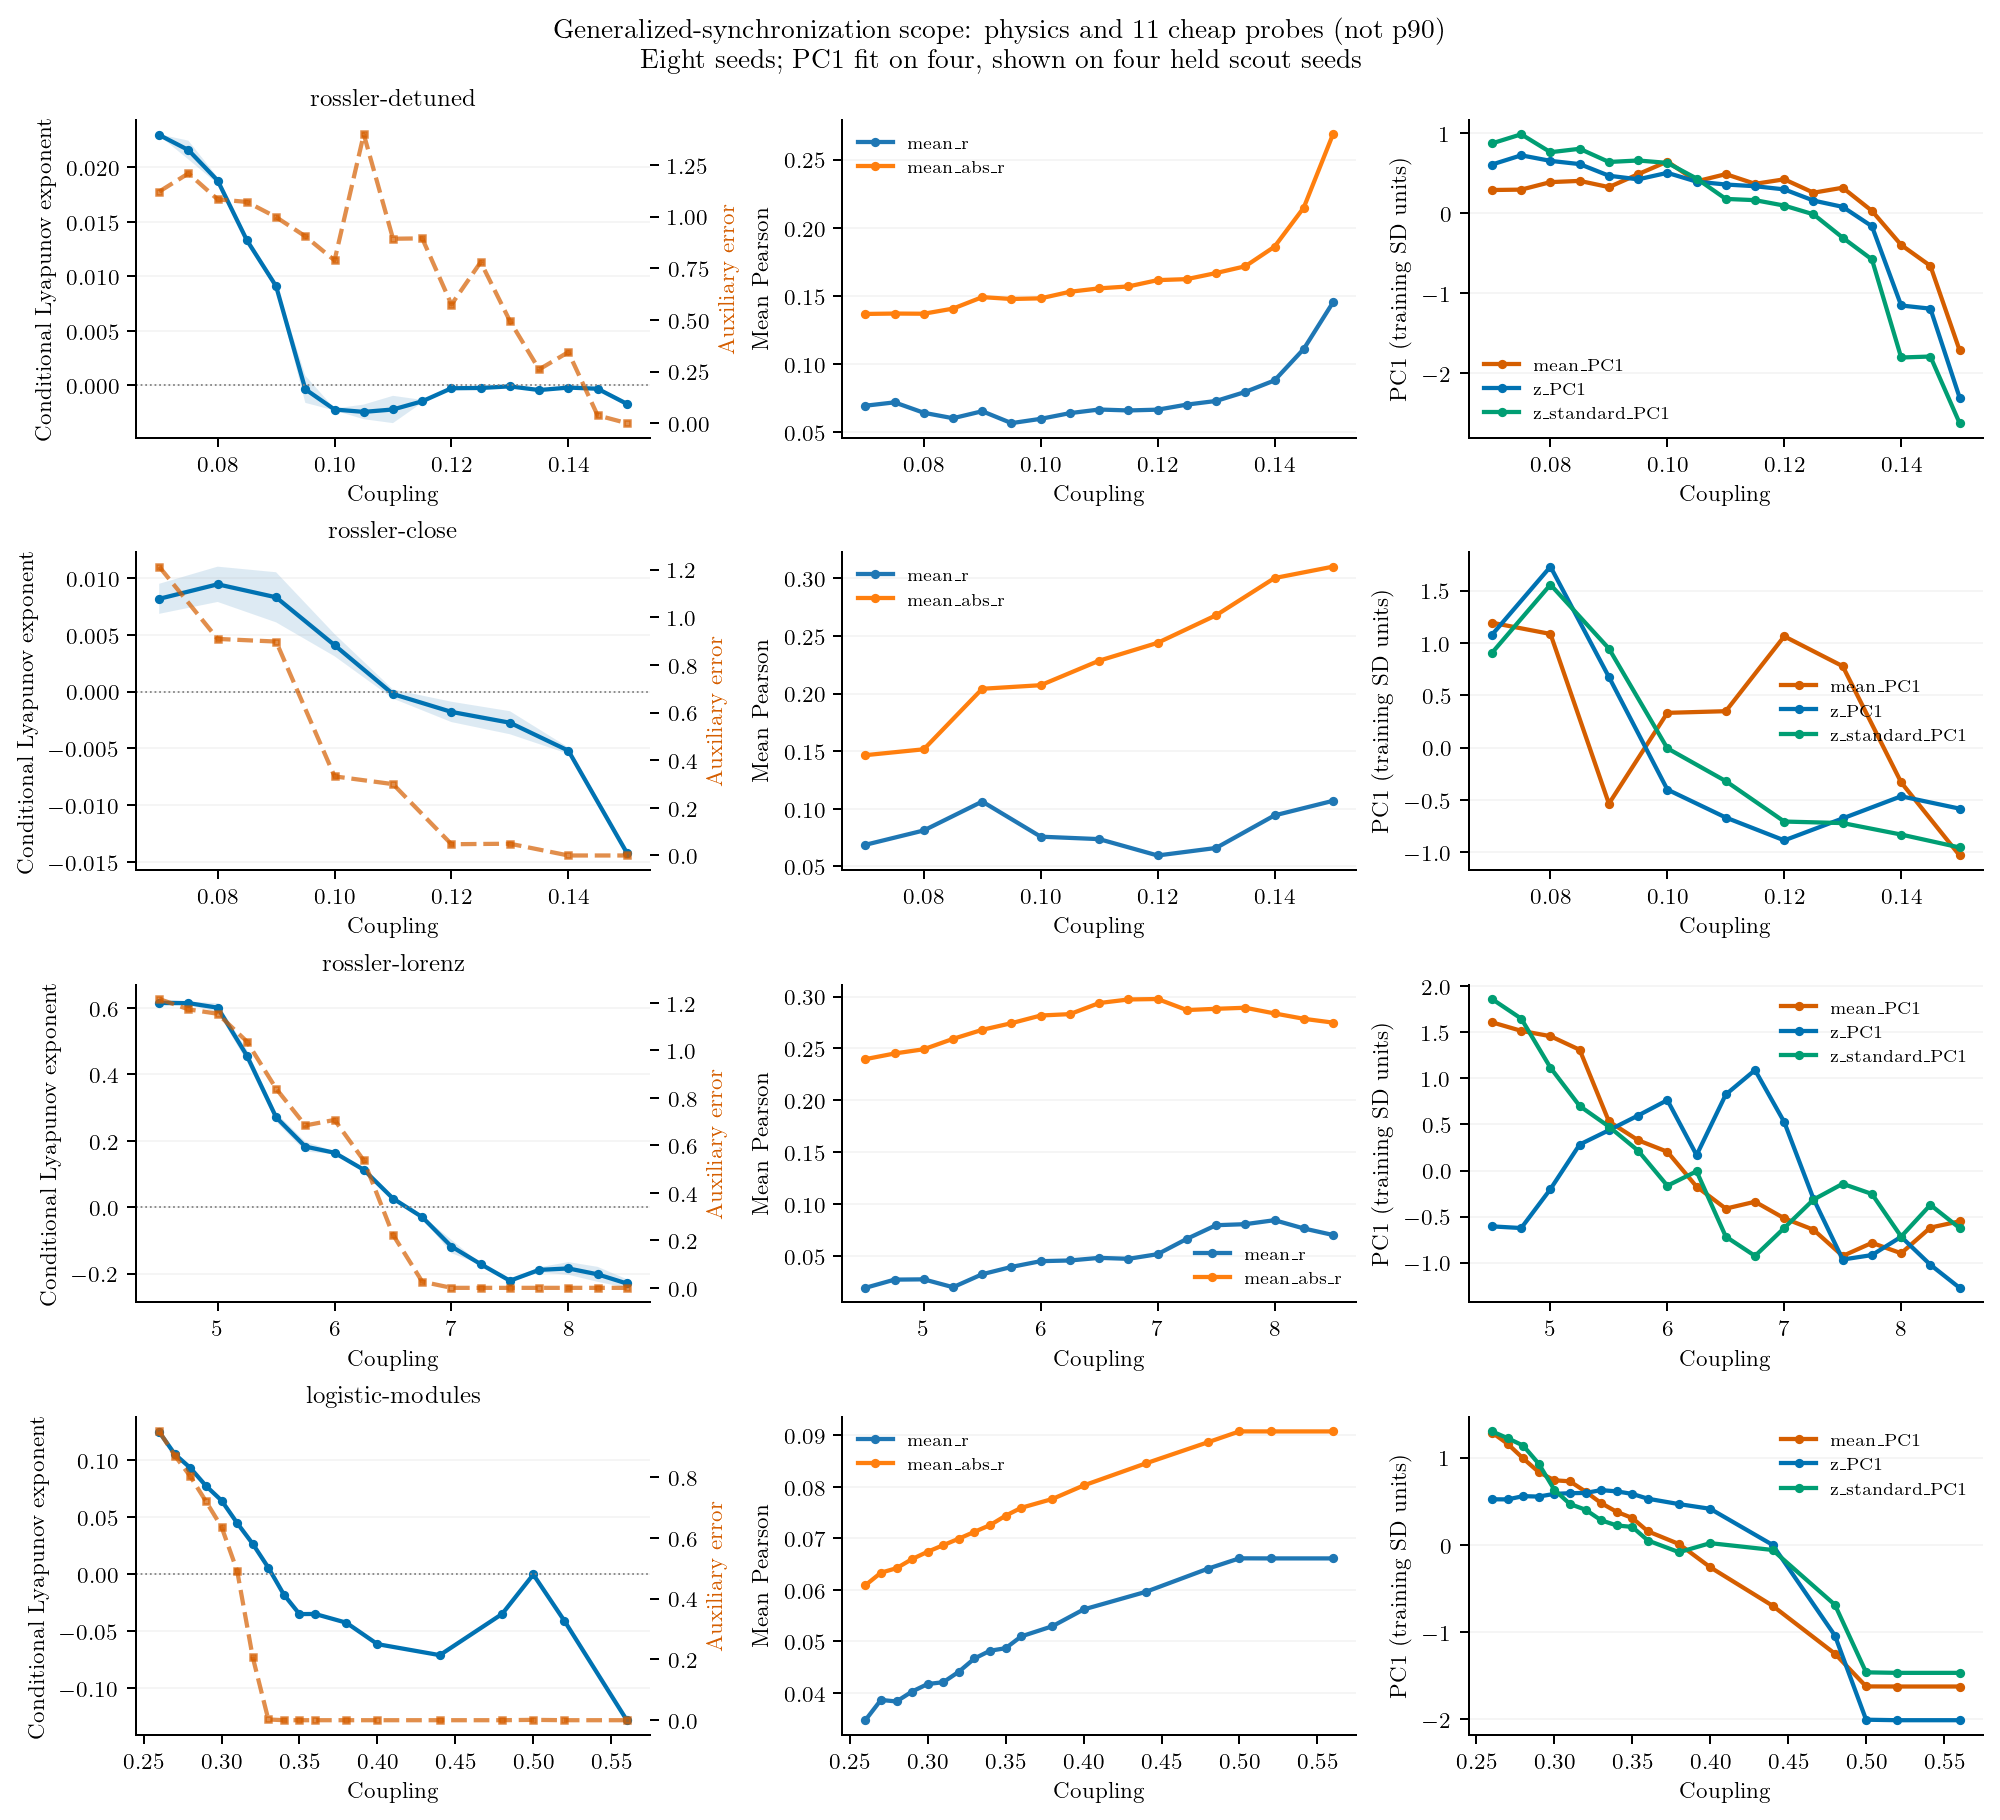

In [2]:
show('physics/physics-and-probes.png')

Longer burn/reference and half-step checks support advancing close-frequency Rössler and Rössler–Lorenz. Detuned Rössler retains conflicting auxiliary/CLE evidence. Logistic auxiliary copies sometimes coalesce numerically while the CLE remains positive: zero auxiliary error alone is not proof of stable synchronization. Cheap-probe comparisons do not establish a general mean-baseline failure.

## Fixed local sweeps: full p90

Two systems × 13 controls × 16 fresh initial-condition seeds: 416 recordings, $M=N=6$, $T=1000$. Eight seeds fit each coordinate; eight evaluate it. Both centered and standardized z-PC1 are reported. Stronger mean baselines include a training-selected individual mean and full-vector ridge/RBF with seed-grouped training-only tuning. No component or narrower interval is selected using evaluation outcomes.

**Result:** SPI–SPI improves on mean signed Pearson here, but no advantage over the stronger mean-vector baselines is established. Close Rössler gives held $|\rho|=.855$ for z-PC1, $.638$ for mean Pearson, $.835$ for mean-PC1 and $.874$ for a supervised mean-vector readout. The last comparison tests information availability, not like-for-like unsupervised performance. Rössler–Lorenz is not a clean sharp z transition. All comparisons use the same eligible records (102/104 and 104/104); two close-Rössler rows exceed the fixed 5% missing-z gate.

Sharpness is separate from correlation: close-Rössler z-PC1 has change-concentration width $.0287$ versus $.0328$ for mean-PC1, but the selected mean is $.0283$ and uncertainty overlaps. No unique sharpness advantage is established. These results concern control sweeps, not within-control fluctuation recovery.

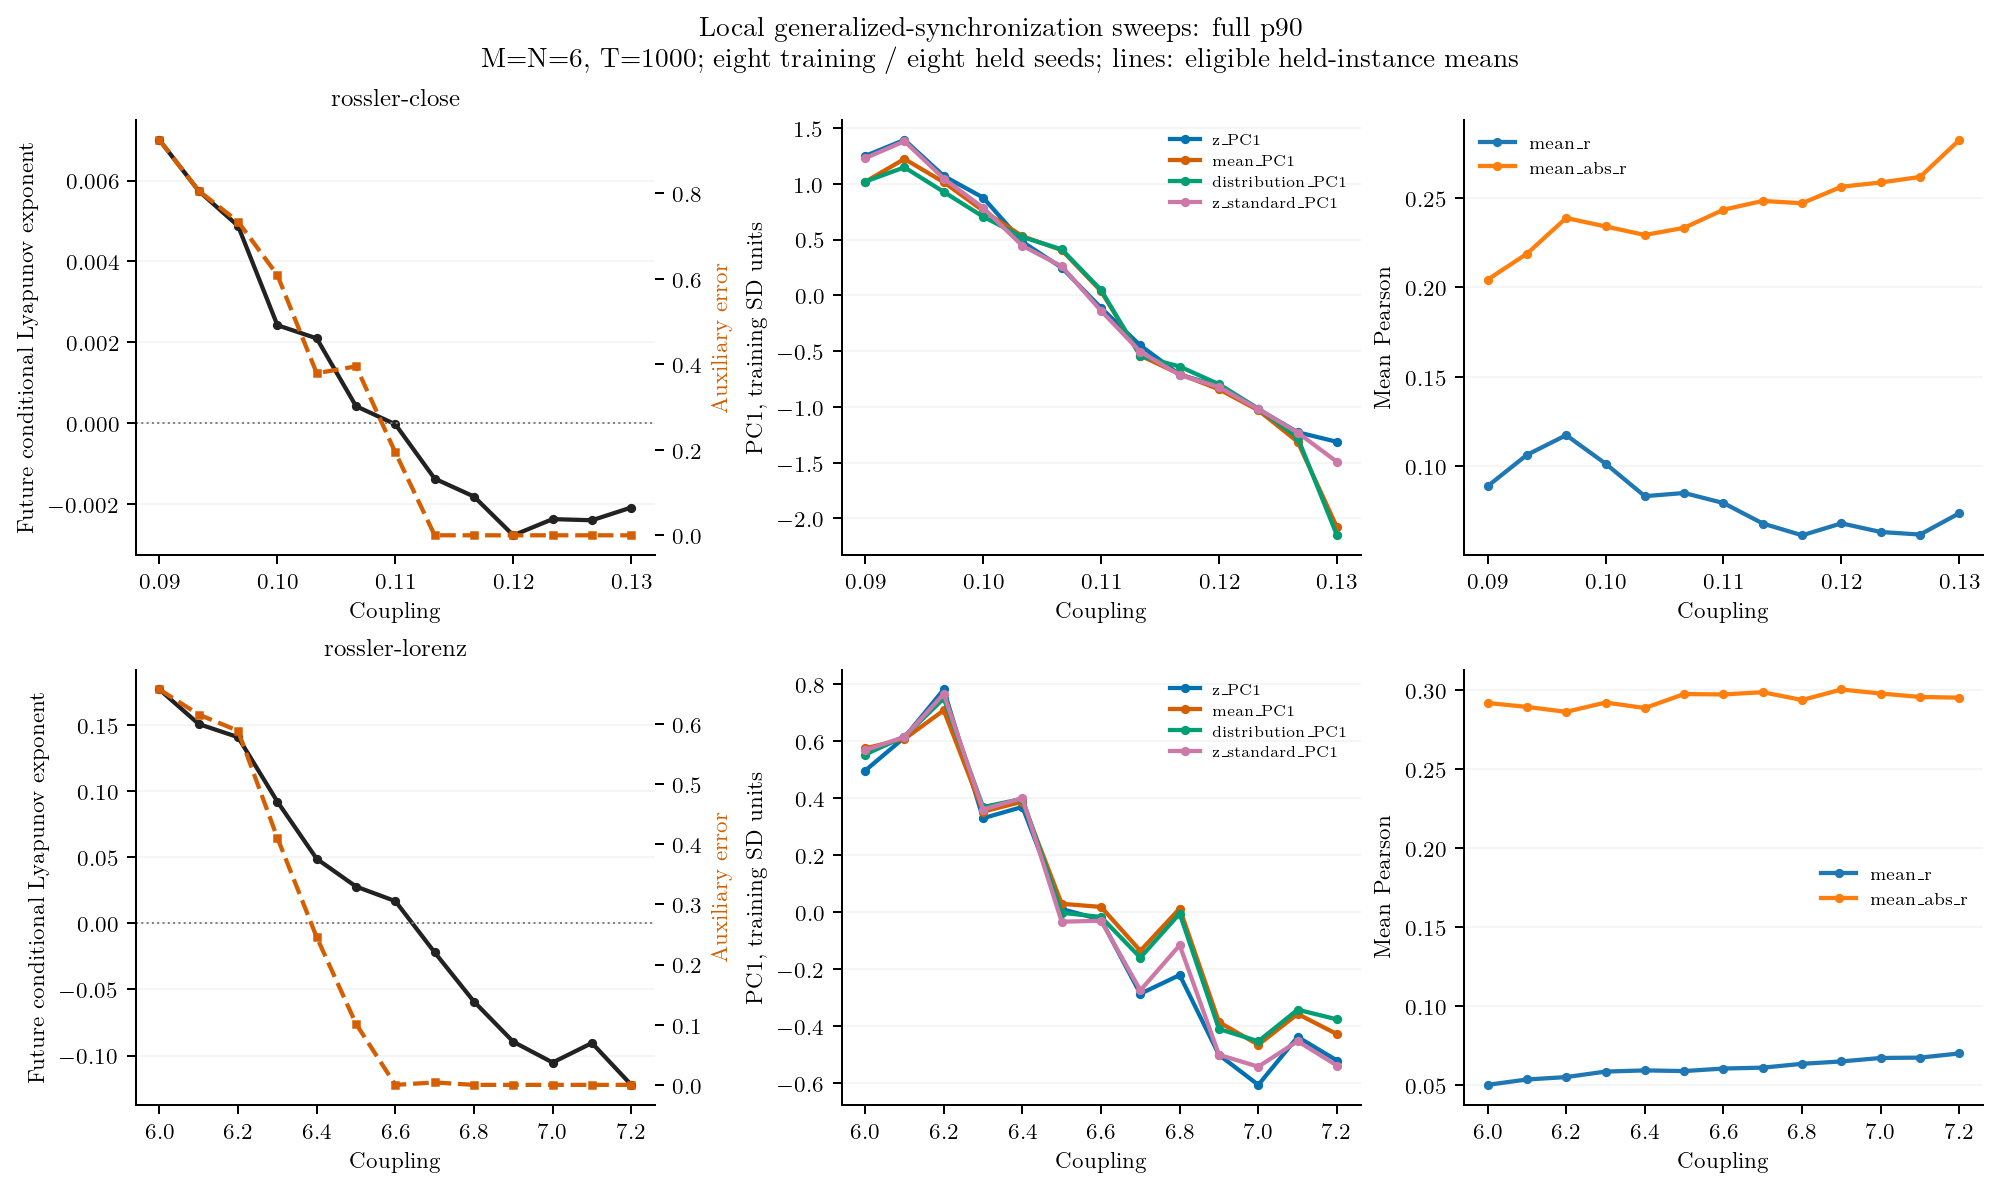

,system,method,n,held_abs_rho
0,rossler-close,z_PC1,102,0.855
1,rossler-close,z_standard_PC1,102,0.851
2,rossler-close,mean_PC1,102,0.835
3,rossler-close,distribution_PC1,102,0.832
4,rossler-close,selected_mean,102,0.845
5,rossler-close,mean_ridge,102,0.868
6,rossler-close,mean_RBF,102,0.874
7,rossler-close,mean_r,102,0.638
8,rossler-close,mean_abs_r,102,0.572
9,rossler-lorenz,z_PC1,104,0.518


In [3]:
if (RESULTS / 'p90/p90-comparison.png').is_file():
    show('p90/p90-comparison.png')
    display(pd.read_csv(RESULTS / 'p90/metrics.csv')[['system', 'method', 'n', 'held_abs_rho']].round(3))
else:
    print('Full-p90 extraction/analysis pending; no full-catalogue advantage claimed.')

## Analytic compositional control: joint extremes

Eight independent bivariate Student-t modules give $M=N=16$. Swap which links combine correlation $\rho=0.1$ or $0.2$ with degrees of freedom $\nu=3$ or $30$, preserving both multisets. Because $I(\rho,\nu)=-\tfrac12\log(1-\rho^2)+c(\nu)$, population mean Pearson, Kendall and MI stay fixed while their pairwise alignment changes. Other SPI means are not assumed fixed.

Ground truth is average upper-tail dependence, $\lambda_U=2t_{\nu+1}(-\sqrt{(\nu+1)(1-\rho)/(1+\rho)})$. This is a known dependence quantity in an engineered stochastic construction, **not a bifurcation**. Nu=3 has finite variance but infinite fourth moment, so finite-sample fluctuations matter.

In [4]:
display(pd.read_csv(RESULTS / 'tail-alignment/population.csv').round(6))
display(pd.read_csv(RESULTS / 'tail-alignment/metrics.csv').round(3))

,swaps,Q_tail,mean_r,mean_tau,mean_MI,z_r_MI
0,0,0.004826,0.01,0.006399,0.00228,0.756106
1,1,0.005101,0.01,0.006399,0.00228,0.802539
2,2,0.005377,0.01,0.006399,0.00228,0.846429
3,3,0.005652,0.01,0.006399,0.00228,0.888153
4,4,0.005928,0.01,0.006399,0.00228,0.928002


,method,held_abs_rho,evr
0,mean_PC1,0.018,0.680
1,z_PC1,0.288,0.789
2,z_standard_PC1,0.404,0.511
3,mean_Pearson,0.008,NaN
4,mean_Spearman,0.012,NaN
5,mean_Kendall,0.006,NaN
6,mean_KSG_MI,0.073,NaN
7,prespecified_z_Pearson_MI,0.271,NaN


The preceding estimates use four focused probes, $T=1000$, 32 training and 32 held seeds per level. The completed p90 extension uses these same 320 records and is therefore exploratory—not fresh confirmation after selecting a favorable toy.

Full-p90 held $|\rho|$: z-PC1 $.402$, mean-PC1 $.035$, mean Pearson $.008$, but the training-selected squared robust-covariance mean reaches $.715$ and full-mean ridge $.753$. All 160 held records are eligible. This is a modest PC1-accessibility contrast, not absence of information from all means.

A post-outcome check gives $|\rho|=.706$ for mean squared robust covariance versus $.013$ after normalizing by its robust diagonal variances. Those scales weight which correlations contribute to the mean; their alignment changes despite fixed population mean Pearson. We retain this strong baseline rather than removing it.

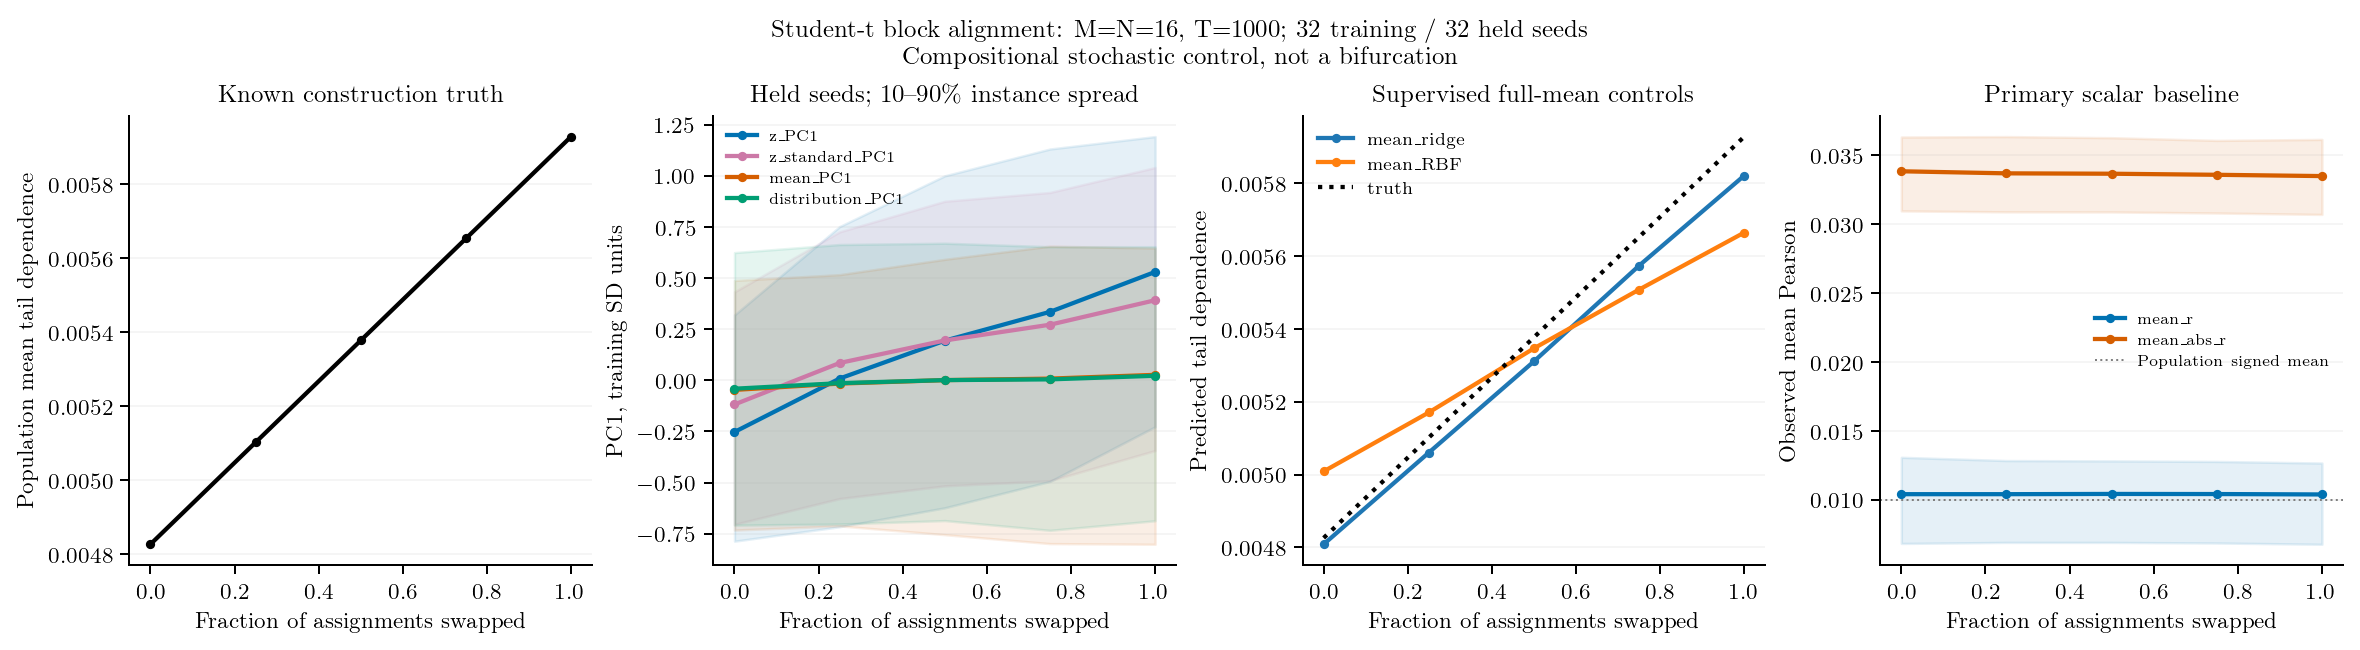

,method,n,held_abs_rho
0,z_PC1,160,0.402
1,z_standard_PC1,160,0.311
2,mean_PC1,160,0.035
3,distribution_PC1,160,0.034
4,selected_mean,160,0.715
5,mean_ridge,160,0.753
6,mean_RBF,160,0.692
7,empirical_mean_r,160,0.008
8,empirical_mean_abs_r,160,0.061


In [5]:
if (RESULTS / 'tail-alignment/p90/p90-tail-comparison.png').is_file():
    show('tail-alignment/p90/p90-tail-comparison.png')
    display(pd.read_csv(RESULTS / 'tail-alignment/p90/metrics.csv')[['method', 'n', 'held_abs_rho']].round(3))
else:
    print('Tail-control p90 extraction/analysis pending.')

## Stationary-to-breathing chimera: physics and inexpensive probes only

[Abrams et al.](https://arxiv.org/html/0806.0594) define two coupled oscillator populations and a continuum Hopf boundary. At $\beta=.1$, $A_H=.27777548$. We observe $x_i=\sin\theta_i$, one process per oscillator, and use future $Q=\operatorname{SD}_t(r_2)$ as an operational breathing-amplitude diagnostic. The continuum boundary is not assumed exact at finite $N$.

The 288-case scout shows substantial finite-size modulation below the continuum onset, particularly with random starts. Mean Pearson is U-shaped, so matching its endpoints alone would be misleading. At $N=M=32$ with random starts, eleven-probe held $|\rho|$ is $.465$ for centered z-PC1, $.849$ for standardized z-PC1, $.641$ for mean-PC1 and $.626$ for signed Pearson. These are two-training/two-validation-seed diagnostics, not p90 or confirmation.

**Not promoted:** standardized z-PC1 is itself U-shaped and correlates more strongly with mean coherence ($|\rho|=.942$) than with breathing amplitude. All M16/M32 recordings also have only 9/17 distinct channels and covariance rank 9/17 because one population synchronizes exactly. Another 288 longer-run/half-step simulations reproduce the physics, but do not remove these structural limitations. No p90 or baseline-superiority claim follows.

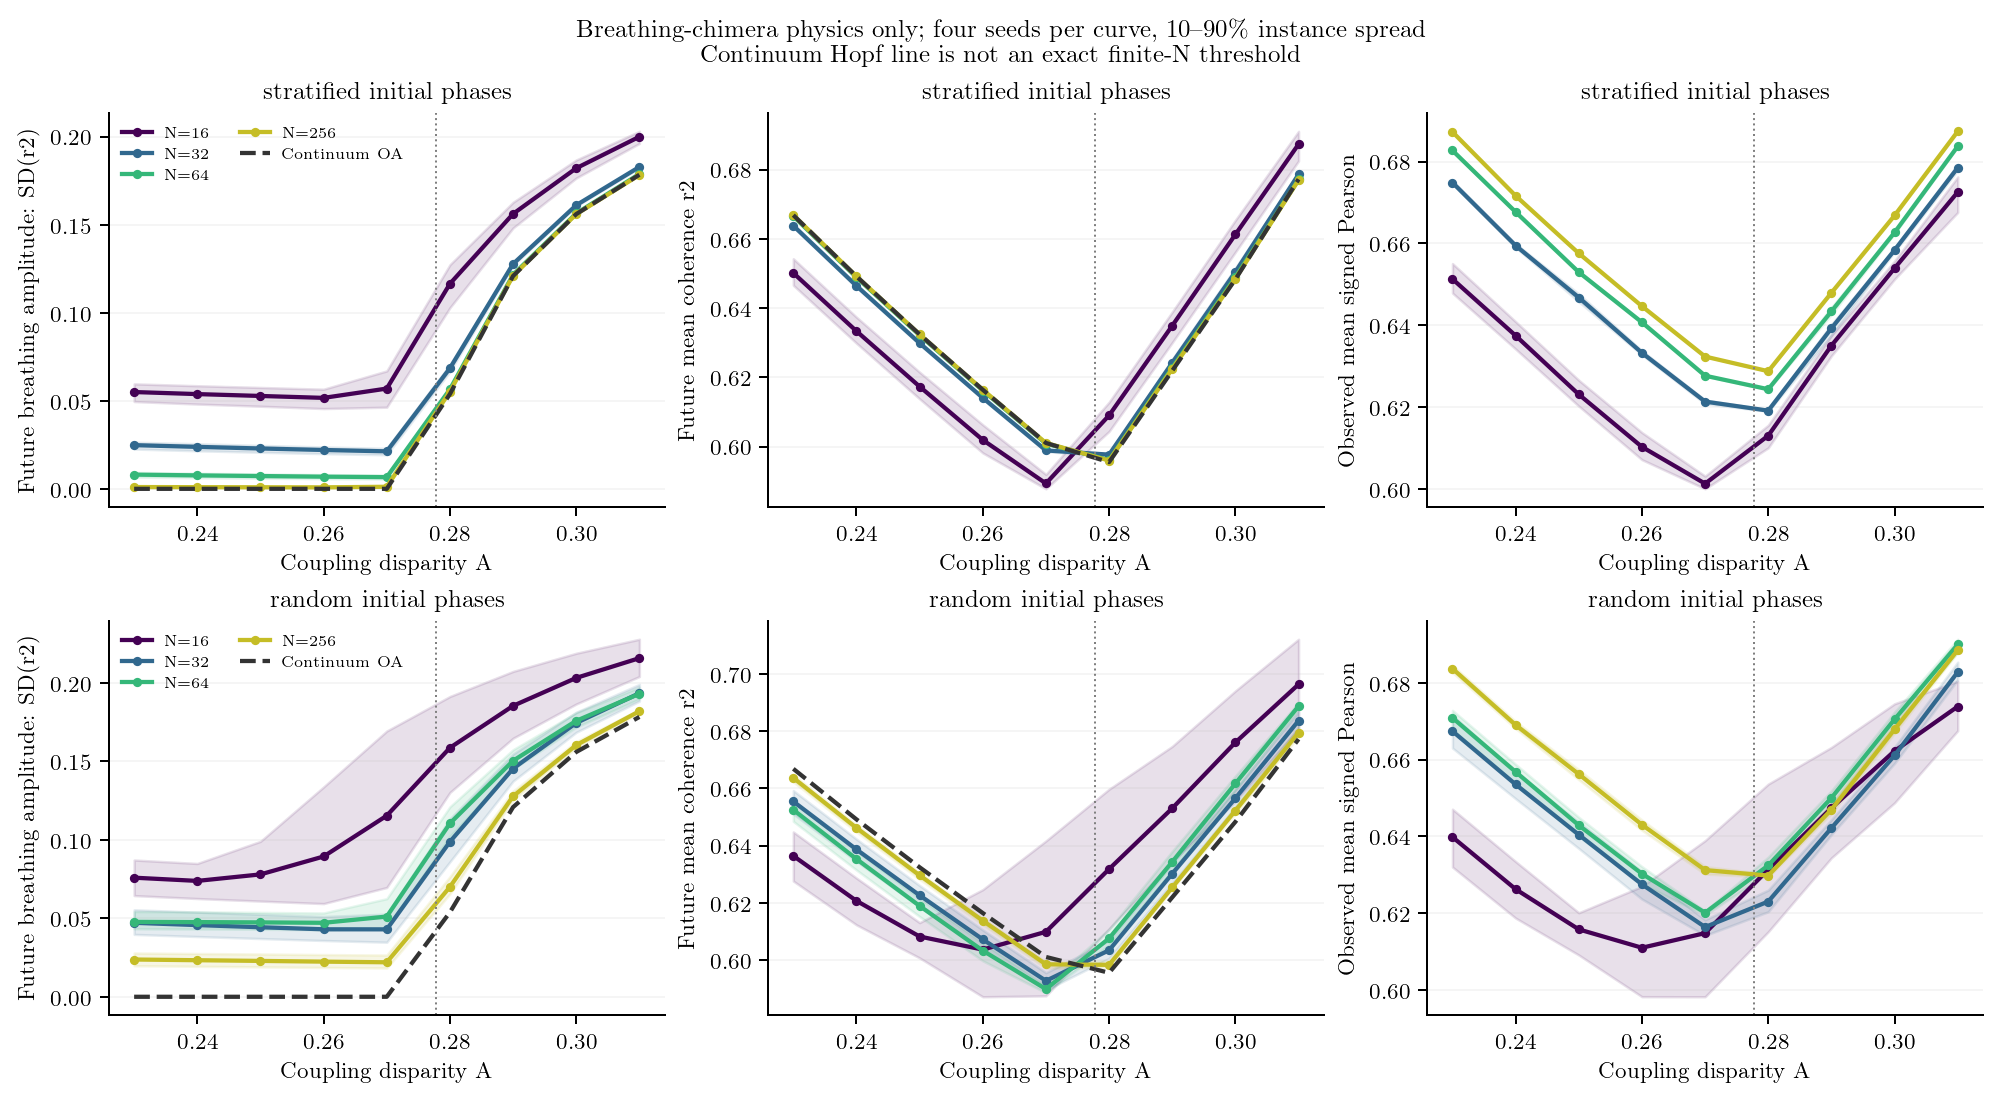

In [6]:
show('chimera-physics/physics.png')

## Separating copula changes from marginal-scale effects

A focused three-arm diagnostic uses 480 independent $M=N=16,T=1000$ recordings. Transforming Student-t margins to Gaussian margins preserves the copula and its analytic tail dependence, but removes the original robust-scale route. Here centered SPI–SPI PC1 still tracks assignment ($\lvert\rho\rvert=.506$), while the four-mean PC1 ($.164$), mean Pearson ($.165$), and squared robust-covariance mean ($.082$) do not show comparable recovery. Conversely, with a Gaussian copula and Student-t margins, the robust mean tracks assignment but Kendall–MI alignment does not.

These are focused probes, **not a full-p90 baseline failure**. Population mean Pearson is approximately, not exactly, matched after the marginal transform. The construction is not a physical bifurcation. The fresh full-p90 test below uses the unchanged Gaussian-margin generator and independent seeds, with all mean-SPI baselines retained.

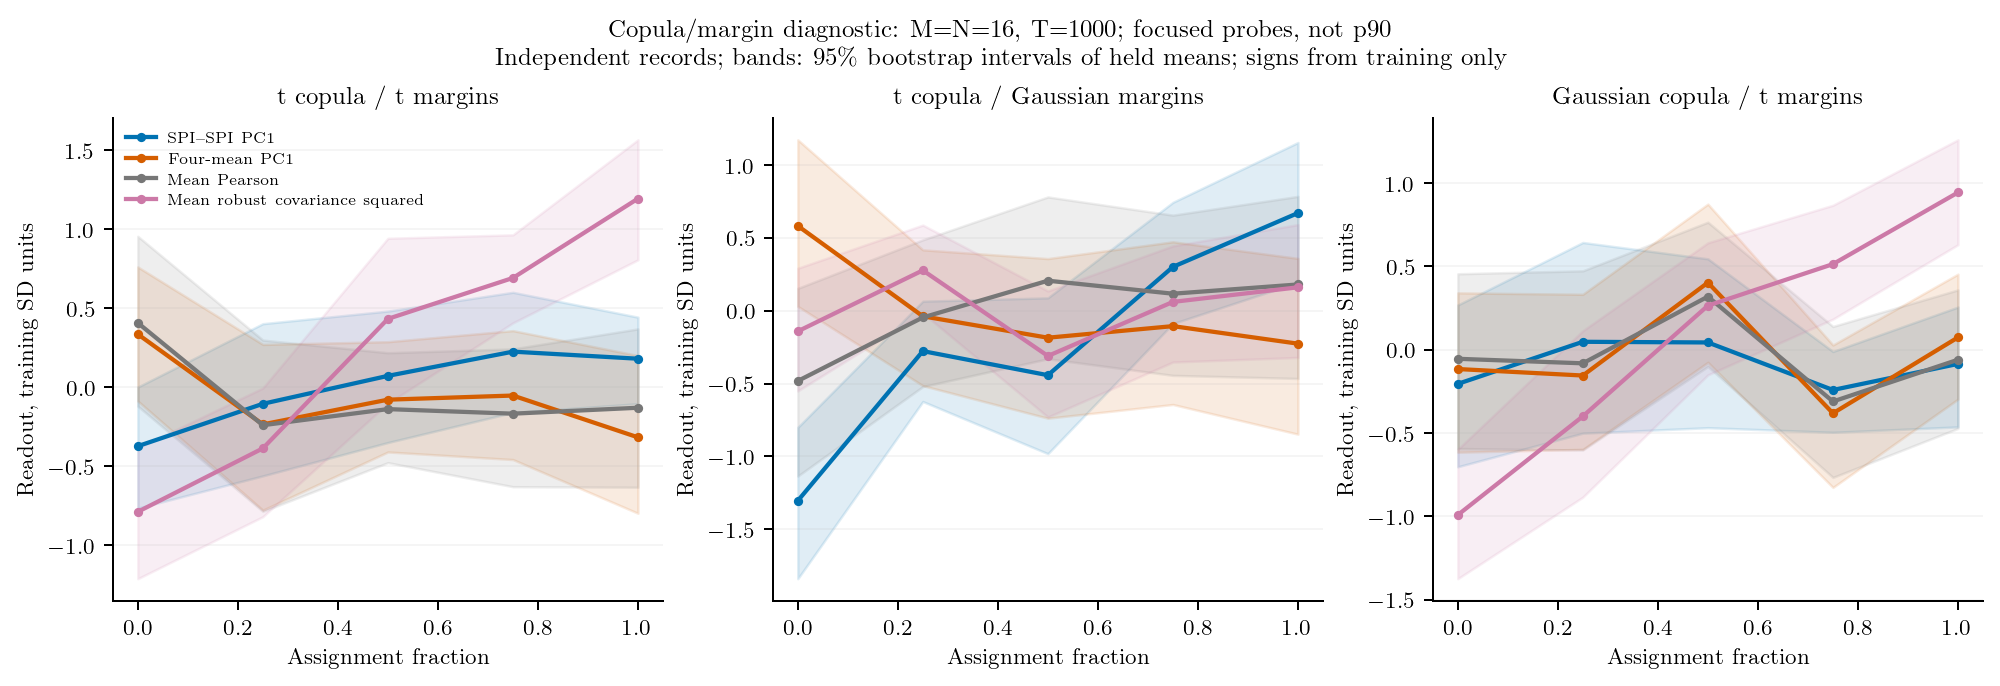

In [7]:
show('copula-margin-diagnostic.png')

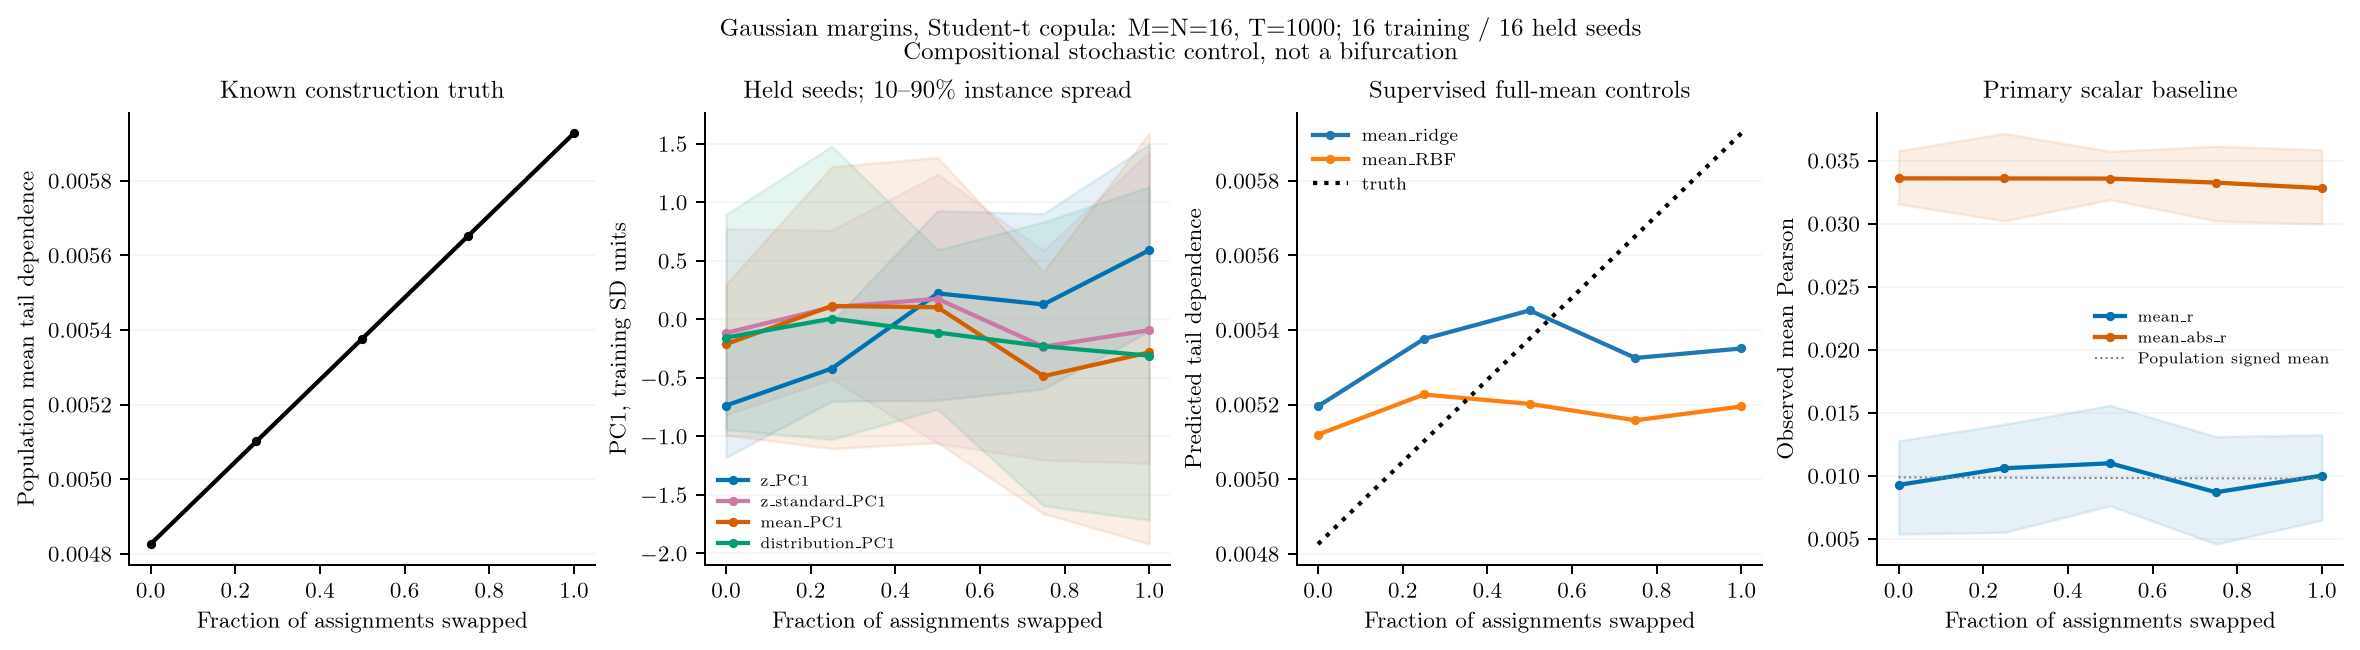

,method,n,held_abs_rho
0,z_PC1,80,0.611
1,z_standard_PC1,80,0.015
2,mean_PC1,80,0.062
3,distribution_PC1,80,0.070
4,selected_mean,80,0.362
5,mean_ridge,80,0.116
6,mean_RBF,80,0.005
7,empirical_mean_r,80,0.044
8,empirical_mean_abs_r,80,0.126


In [8]:
if (RESULTS / 'normal-margin-p90/p90-tail-comparison.png').is_file():
    show('normal-margin-p90/p90-tail-comparison.png')
    display(pd.read_csv(RESULTS / 'normal-margin-p90/metrics.csv')[['method', 'n', 'held_abs_rho']].round(3))
else:
    print('Fresh Gaussian-margin full-p90 test: running; no full-mean conclusion yet.')

Full p90: all 80 held records pass. Centered z-PC1 reaches $|\rho|=.611$, compared with $.062$ for mean-PC1 and $.044$ for signed Pearson. The training-selected IDS mean retains signal ($.362$); full-mean ridge/RBF reach $.116/.005$. **Promising, not definitive:** standardized z-PC1 fails ($.015$), centered PC1 explains only $6.13\%$ of z variance, and the mean models have only 80 training records for 262 variable means. This is a smooth compositional dependence change, not a sharp physical transition.

A fixed-generator replication adds 320 independent recordings: 160 additional training and 160 fresh held. It evaluates the original PC1 unchanged and separately expands training from 80 to 240 records for all readouts. Original evaluation records are excluded from the new experiment. No component, generator parameter or control window is selected on the new outcomes.

In [9]:
if (RESULTS / 'normal-margin-replication/replication-comparison.png').is_file():
    show('normal-margin-replication/replication-comparison.png')
else:
    print('Fixed-readout replication and enlarged-training comparison pending.')

Fixed-readout replication and enlarged-training comparison pending.


[Protocol, equations, sources, failures and reproduction](../../docs/research/order-parameter-benchmarks/dependence-transition-261005.md). Existing polished benchmark notebooks are unchanged.